# Greenfilling: slowdown versus area-weighted response time

The [workload notebook](workload_characterization.ipynb) showed that narrow-short jobs are numerous but use little node-time. The [slowdown notebook](greenfilling_slowdown_by_class.ipynb) showed that these jobs explain most of Greenfilling's increase in **mean bounded slowdown**. Here we ask: **does the conclusion change when jobs are weighted by the amount of work they perform?**

We use the same four workloads, 36 environmental windows, and carbon/water objectives. Each Greenfilling run is compared with EASY using the **same replay jobs**. Context jobs are excluded.

The metric comes from [Boëzennec et al. (2024), Section 2.3.2, Eq. (4)](https://people.bordeaux.inria.fr/gaupy/ressources/pub/journals/qualitatively_analyzing_hpc.pdf). The paper calls it WRT. We call it **area-weighted response time (WRT)** here.

## What the two metrics measure

A job's **response time** is its waiting time plus its execution time. Its **area** is the number of requested nodes times its actual execution time. We calculate:

`WRT = sum(job area × job response time) / sum(job area)`

Our experiments request **nodes**, so area is measured in **node-seconds**. WRT is reported in hours. Lower is better.

Mean bounded slowdown instead gives each job one equal vote: `mean(max(response time / max(execution time, 10 seconds), 1))`. A short job's wait can be many times its runtime, so short jobs are expected to affect this mean strongly. WRT asks a different question: how long does a unit of computational work take to finish?

Both schedulers execute the same jobs for the same duration. Thus, for a matched pair, the **change in WRT is the area-weighted change in waiting time**. The code checks this identity.

## Setup and campaign inventory

In [11]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display


def find_repository_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / 'analysis' / 'greenfilling_weighted_response_time_analysis.py').exists():
            return candidate
    raise FileNotFoundError('Run this notebook inside the experimental-artifacts checkout')


ROOT = find_repository_root(Path.cwd().resolve())
ANALYSIS_DIR = ROOT / 'analysis'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import greenfilling_weighted_response_time_analysis as wrt

pd.set_option('display.max_columns', 120)
ROOT

PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts')

In [12]:
manifest = wrt.slowdown.expected_manifest()
display(wrt.slowdown.completeness_summary(manifest))
print(f"Available job CSVs: {manifest['has_jobs'].sum()} / {len(manifest)}")

expected  available
workload       variant                                 
mustang_stress easy_bf                    36         36
               greenfilling_carbon        36         36
               greenfilling_water         36         36
mustang_slack  easy_bf                    36         36
               greenfilling_carbon        36         36
               greenfilling_water         36         36
trinity_stress easy_bf                    36         36
               greenfilling_carbon        36         36
               greenfilling_water         36         36
trinity_slack  easy_bf                    36         36
               greenfilling_carbon        36         36
               greenfilling_water         36         36

Available job CSVs: 432 / 432


One **environmental window** is a location and start date with about four weeks of carbon and water data. There are 36 windows per workload and three schedules per window: EASY, Greenfilling-carbon, and Greenfilling-water. That makes **432 job-output files**. The loader checks job IDs, node requests, and execution times before comparing schedules.

In [13]:
totals, by_class = wrt.load_paired_metrics(manifest)
print(f'{len(totals)} EASY–Greenfilling comparisons; {len(by_class)} class results')

288 EASY–Greenfilling comparisons; 864 class results


## Compare the complete schedules

Each row below summarizes **36 matched windows** for one workload and objective. A positive change means Greenfilling is worse than EASY. Percentages compare Greenfilling with EASY **within each window**, then take the median. The WRT columns also show the actual times, so a small percentage is not confused with a large delay.

`bsld_worse_windows` and `wrt_worse_windows` count how often each metric increases; the maximum is 36. WRT change is also shown in seconds because Trinity stress changes are too small to see when rounded to hours.

In [14]:
total_summary = wrt.summarize_totals(totals)
display(total_summary.drop(columns='both_success_wrt_worse_windows'))

windows  median_bsld_change_pct  \
workload       objective                                    
mustang_stress carbon          36                 174.984   
               water           36                 161.525   
mustang_slack  carbon          36                 323.578   
               water           36                 308.467   
trinity_stress carbon          36                 226.564   
               water           36                 213.246   
trinity_slack  carbon          36                 210.127   
               water           36                 211.514   

                          median_easy_wrt_hours  median_green_wrt_hours  \
workload       objective                                                  
mustang_stress carbon                    40.080                  43.058   
               water                     40.080                  43.014   
mustang_slack  carbon                    20.942                  21.414   
               water                     20.942                  21.327   
trinity_stress carbon                    12.879                  12.881   
               water                     12.879                  12.879   
trinity_slack  carbon                    12.380                  12.486   
               water                     12.380                  12.478   

                          median_wrt_change_seconds  median_wrt_change_pct  \
workload       objective                                                     
mustang_stress carbon                     10718.683                  7.429   
               water                      10561.609                  7.320   
mustang_slack  carbon                      1698.325                  2.253   
               water                       1384.290                  1.836   
trinity_stress carbon                         5.196                  0.011   
               water                         -1.259                 -0.003   
trinity_slack  carbon                       381.274                  0.856   
               water                        353.365                  0.793   

                          bsld_worse_windows  wrt_worse_windows  
workload       objective                                         
mustang_stress carbon                     36                 36  
               water                      36                 36  
mustang_slack  carbon                     36                 36  
               water                      36                 36  
trinity_stress carbon                     36                 22  
               water                      36                 18  
trinity_slack  carbon                     36                 35  
               water                      36                 34

Slowdown rises in all **288** comparisons. WRT also rises in every Mustang comparison, but by much less: about **7.3–7.4%** in Mustang stress and **1.8–2.3%** in Mustang slack, compared with roughly **162–324%** for slowdown.

In Trinity slack, the median WRT increase is below **1%**. In Trinity stress it is approximately **zero**: about **+5 seconds** for carbon and **−1 second** for water. These are medians, not one pooled schedule. We should not interpret the small Trinity-stress sign difference as a meaningful performance win.

In [15]:
display(wrt.compare_metric_signs(totals))

both_worse  slowdown_worse_wrt_better  \
workload       objective                                          
mustang_stress carbon             36                          0   
               water              36                          0   
mustang_slack  carbon             36                          0   
               water              36                          0   
trinity_stress carbon             22                         14   
               water              18                         18   
trinity_slack  carbon             35                          1   
               water              34                          2   

                          slowdown_better_wrt_worse  both_better  
workload       objective                                          
mustang_stress carbon                             0            0  
               water                              0            0  
mustang_slack  carbon                             0            0  
               water                              0            0  
trinity_stress carbon                             0            0  
               water                              0            0  
trinity_slack  carbon                             0            0  
               water                              0            0

The two metrics sometimes prefer different schedules, mainly in Trinity stress. In those windows, slowdown worsens while WRT improves **slightly**. Check the size of a change as well as its sign.

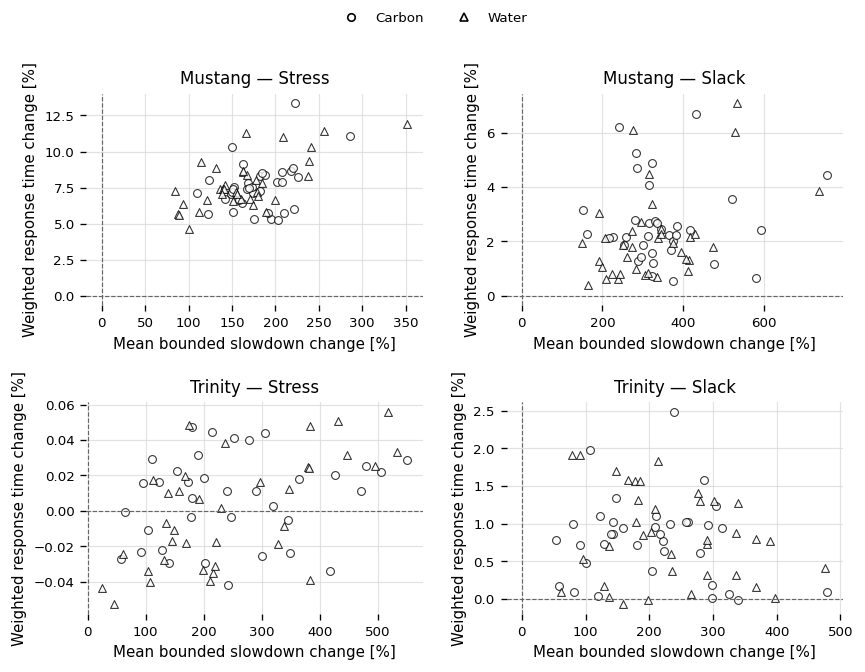

[PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures/greenfilling_slowdown_vs_weighted_response_time.pdf'),
 PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures/greenfilling_slowdown_vs_weighted_response_time.png')]

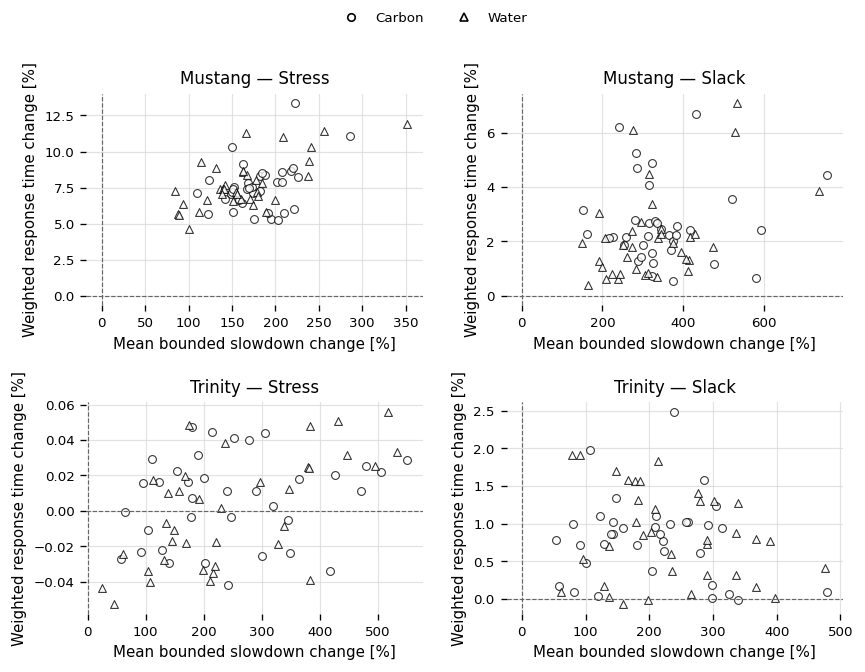

In [16]:
fig = wrt.plot_total_changes(totals)
display(fig)
wrt.export_figure(fig, 'greenfilling_slowdown_vs_weighted_response_time')

Each point is one Greenfilling–EASY comparison. The dashed lines mark no change. The axes have **different scales in each panel**, especially because Trinity-stress WRT changes are close to zero.

## Which job groups drive each metric?

We keep the previous notebook's groups: **narrow-short** jobs use at most 1% of the platform and run for at most 2 hours; **wide** jobs use at least 10%; **other** holds the rest. These groups cover every replay job without overlap.

Slowdown gives equal weight to jobs, so a group's weight is its **share of jobs**. WRT weights jobs by node-seconds, so a group's weight is its **share of area**. These shares are properties of the workload and do not change across windows.

In [17]:
class_summary = wrt.summarize_classes(by_class)
display(class_summary.loc[pd.IndexSlice[:, 'carbon', :], ['jobs', 'job_share_pct', 'area_share_pct']].droplevel('objective'))

jobs  job_share_pct  area_share_pct
workload       job_class                                        
mustang_stress narrow-short  3199         62.861           0.206
               other         1655         32.521          41.640
               wide           235          4.618          58.155
mustang_slack  narrow-short  4803         44.959           0.828
               other         5608         52.495          49.036
               wide           272          2.546          50.136
trinity_stress narrow-short  2300         65.027           0.068
               other          713         20.158          13.390
               wide           524         14.815          86.542
trinity_slack  narrow-short  3329         72.025           0.094
               other          730         15.794          15.145
               wide           563         12.181          84.761

For each window, a group's contribution is its **weight × its average change**:

- Slowdown contribution = job share × average slowdown change in the group.
- WRT contribution = area share × area-weighted response-time change in the group.

The three contributions add exactly to the **overall change in that window**. The table below reports the *median* contribution across windows. Medians calculated separately need not add up. A negative contribution means that group improved while other groups may have worsened.

In [18]:
display(class_summary[['median_class_bsld_change', 'median_bsld_contribution',
                       'median_class_wrt_change_hours', 'median_wrt_contribution_seconds']])

median_class_bsld_change  \
workload       objective job_class                                
mustang_stress carbon    narrow-short                   349.471   
                         other                          143.239   
                         wide                            96.853   
               water     narrow-short                   310.814   
                         other                          134.297   
                         wide                           103.629   
mustang_slack  carbon    narrow-short                   448.250   
                         other                           21.723   
                         wide                           -20.975   
               water     narrow-short                   427.327   
                         other                           20.935   
                         wide                           -20.460   
trinity_stress carbon    narrow-short                     8.570   
                         other                            0.781   
                         wide                            -0.457   
               water     narrow-short                     7.981   
                         other                            0.774   
                         wide                            -0.461   
trinity_slack  carbon    narrow-short                     7.183   
                         other                            0.874   
                         wide                            -0.427   
               water     narrow-short                     7.057   
                         other                            0.785   
                         wide                            -0.320   

                                       median_bsld_contribution  \
workload       objective job_class                                
mustang_stress carbon    narrow-short                   219.681   
                         other                           46.583   
                         wide                             4.472   
               water     narrow-short                   195.381   
                         other                           43.675   
                         wide                             4.785   
mustang_slack  carbon    narrow-short                   201.530   
                         other                           11.403   
                         wide                            -0.534   
               water     narrow-short                   192.123   
                         other                           10.990   
                         wide                            -0.521   
trinity_stress carbon    narrow-short                     5.573   
                         other                            0.158   
                         wide                            -0.068   
               water     narrow-short                     5.190   
                         other                            0.156   
                         wide                            -0.068   
trinity_slack  carbon    narrow-short                     5.174   
                         other                            0.138   
                         wide                            -0.052   
               water     narrow-short                     5.083   
                         other                            0.124   
                         wide                            -0.039   

                                       median_class_wrt_change_hours  \
workload       objective job_class                                     
mustang_stress carbon    narrow-short                          3.921   
                         other                                 4.863   
                         wide                                  1.464   
               water     narrow-short                          3.870   
                         other                                 4.870   
                         wide                    

In **Mustang slack**, the negative contributions from wide jobs may be an indirect effect of the environmental gate. By refusing some backfills when the signal is unfavorable, Greenfilling may leave more nodes free when a wide job is ready to start. This is a plausible explanation, not a causal conclusion from the job outputs.

`median_class_*_change` describes a typical change **within that group**. `median_*_contribution` describes how much the group adds to the **whole-schedule** change. The WRT contribution is in **seconds** to keep small values visible; the within-group WRT change is in **hours**. These metrics have different units, so compare their patterns and relative changes, not their raw numbers.

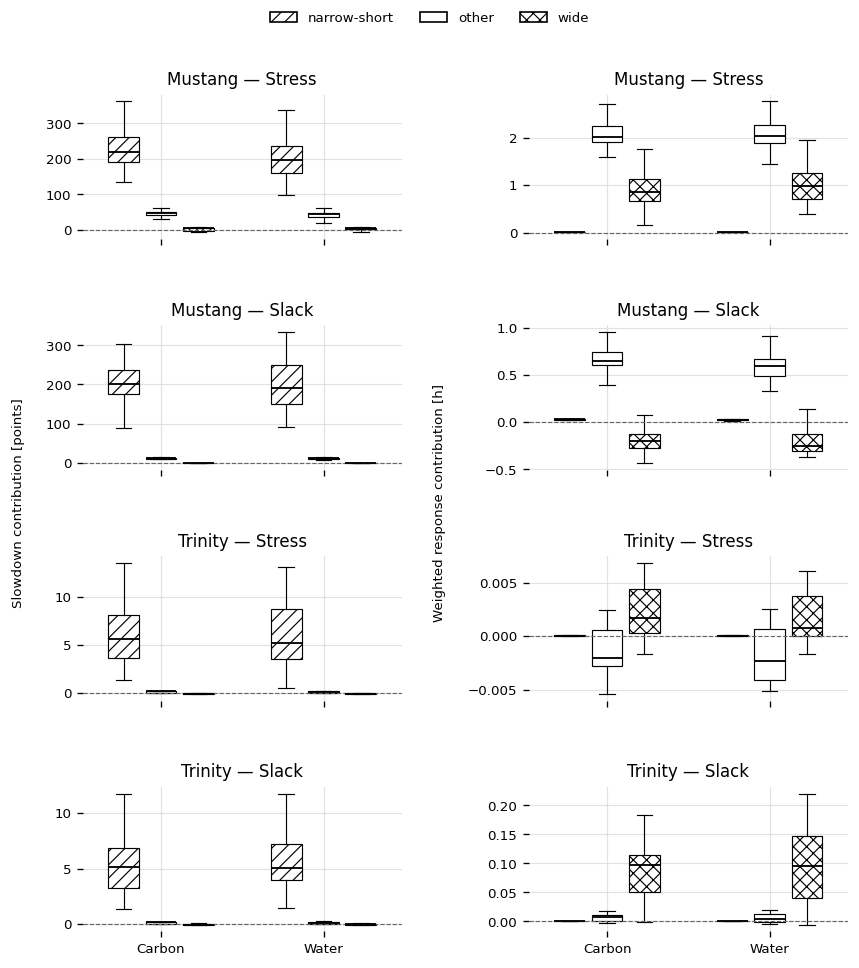

[PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures/greenfilling_metric_contributions_by_class.pdf'),
 PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures/greenfilling_metric_contributions_by_class.png')]

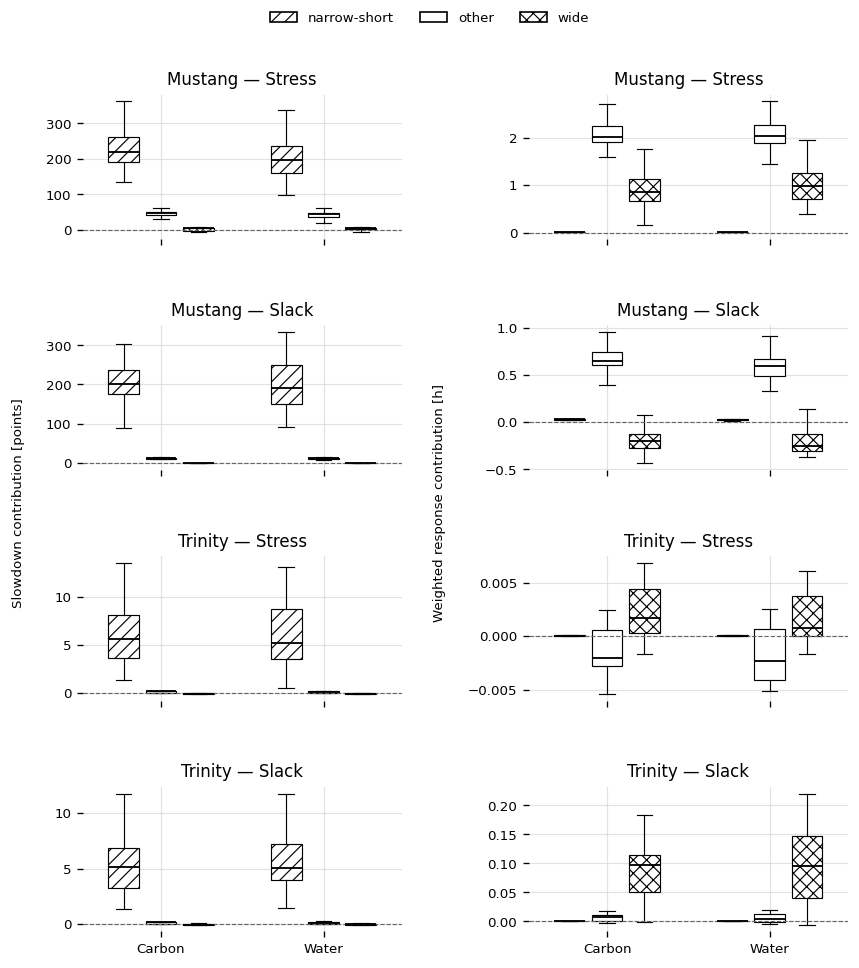

In [19]:
fig = wrt.plot_class_contributions(by_class)
display(fig)
wrt.export_figure(fig, 'greenfilling_metric_contributions_by_class')

Each box covers 36 windows. Outlier dots are hidden for readability, but those windows remain in the tables. The two columns use different units; compare groups **within** a column and workload.

## Check jobs stopped at walltime

Like the previous campaign analysis, the main results include replay jobs stopped at their walltime limit. The check below recalculates WRT using only jobs that finished successfully under **both** schedulers in each matched window. It tests whether stopped jobs alone explain the WRT result; this subset is not the main metric.

In [20]:
display(total_summary[['wrt_worse_windows', 'both_success_wrt_worse_windows']])

wrt_worse_windows  both_success_wrt_worse_windows
workload       objective                                                   
mustang_stress carbon                    36                              36
               water                     36                              36
mustang_slack  carbon                    36                              36
               water                     36                              36
trinity_stress carbon                    22                              24
               water                     18                              18
trinity_slack  carbon                    35                              36
               water                     34                              35

## Interpretation

Narrow-short jobs dominate the **slowdown** penalty, as expected for a metric that divides waiting by runtime. But they represent only **0.07–0.83%** of node-seconds. Their contribution to the **overall WRT change** is therefore tiny, even when their own response times rise.

WRT gives more weight to the other and wide jobs. For Mustang stress, it still finds a real penalty: about **3 extra hours**, or **7%**, in a typical window. For Mustang slack and Trinity slack the penalty is smaller; for Trinity stress it is near zero. The result is therefore **not** that Greenfilling has no performance cost. Rather, the size and even the presence of the penalty depend strongly on what the metric values.

